# Preparing Data

In [1]:
pip install iterative-stratification

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    hamming_loss
)

from iterstrat.ml_stratifiers import MultilabelStratifiedKFold
from xgboost import XGBClassifier

import matplotlib.pyplot as plt

In [3]:
import joblib

search_lr = joblib.load("/kaggle/input/notebooks/alyssandra14/6-model-building/models/lr_model.pkl")
search_dt = joblib.load("/kaggle/input/notebooks/alyssandra14/6-model-building/models/dt_model.pkl")
search_rf = joblib.load("/kaggle/input/notebooks/alyssandra14/6-model-building/models/rf_model.pkl")
search_lgbm = joblib.load("/kaggle/input/notebooks/alyssandra14/6-model-building/models/lgbm_model.pkl")
search_xgb_multi = joblib.load("/kaggle/input/notebooks/alyssandra14/6-model-building/models/xgb_multi_model.pkl")
model_xgb_loop_tuned = joblib.load("/kaggle/input/notebooks/alyssandra14/6-model-building/models/xgb_loop_model.pkl")

/usr/lib/python3.12/pickle.py:1760: UserWarning: [04:53:20] WARNING: /__w/xgboost/xgboost/src/gbm/gbtree.cc:402: Changing updater from `grow_gpu_hist` to `grow_quantile_histmaker`.
  setstate(state)
/usr/lib/python3.12/pickle.py:1760: UserWarning: [04:53:20] WARNING: /__w/xgboost/xgboost/src/context.cc:53: No visible GPU is found, setting device to CPU.
  setstate(state)
/usr/lib/python3.12/pickle.py:1760: UserWarning: [04:53:20] WARNING: /__w/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  setstate(state)
/usr/lib/python3.12/pickle.py:1760: UserWarning: [04:53:21] WARNING: /__w/xgboost/xgboost/src/gbm/gbtree.cc:402: Changing updater from `grow_gpu_hist` to `grow_quantile_histmaker`.
  setstate(state)
/usr/lib/python3.12/pickle.py:1760: UserWarning: [04:53:21] WARNING: /__w/xgboost/xgboost/src/context.cc:53: No visible GPU is found, setting device to CPU.
  setstate(state)
/usr/lib/python3.12/pickle.py:1760: U

In [4]:
X_train        = np.load("/kaggle/input/datasets/alyssandra14/split-data-and-json-col-with-rf-imputer/X_train.npy")
X_train_scaled = np.load("/kaggle/input/datasets/alyssandra14/split-data-and-json-col-with-rf-imputer/X_train_scaled.npy")
X_val          = np.load("/kaggle/input/datasets/alyssandra14/split-data-and-json-col-with-rf-imputer/X_val.npy")
X_val_scaled   = np.load("/kaggle/input/datasets/alyssandra14/split-data-and-json-col-with-rf-imputer/X_val_scaled.npy")
X_test         = np.load("/kaggle/input/datasets/alyssandra14/split-data-and-json-col-with-rf-imputer/X_test.npy")
X_test_scaled  = np.load("/kaggle/input/datasets/alyssandra14/split-data-and-json-col-with-rf-imputer/X_test_scaled.npy")

y_test         = np.load("/kaggle/input/datasets/alyssandra14/split-data-and-json-col-with-rf-imputer/y_test.npy")
y_train        = np.load("/kaggle/input/datasets/alyssandra14/split-data-and-json-col-with-rf-imputer/y_train.npy")
y_val          = np.load("/kaggle/input/datasets/alyssandra14/split-data-and-json-col-with-rf-imputer/y_val.npy")

In [5]:
import json

with open("/kaggle/input/datasets/alyssandra14/split-data-and-json-col-with-rf-imputer/reaction_cols.json", "r") as f:
    reaction_cols = json.load(f)

with open("/kaggle/input/datasets/alyssandra14/split-data-and-json-col-with-rf-imputer/feature_cols.json", "r") as f:
    feature_cols = json.load(f)

In [6]:
with open("/kaggle/input/notebooks/alyssandra14/6-model-building/best_xgb_loop_params.json", "r") as f:
    best_xgb_loop_params = json.load(f)

In [7]:
# ── Class weights per reaction (for imbalance handling) ───────────
# saving scale_pos_weight
print(f"\nClass imbalance ratios (neg/pos):")
scale_pos_weight = {}
for i, col in enumerate(reaction_cols):
    pos = y_train[:, i].sum()
    neg = len(y_train) - pos
    ratio = neg / pos if pos > 0 else 999
    scale_pos_weight[col] = ratio
    print(f"  {col:<35} {ratio:>8.1f}x")


Class imbalance ratios (neg/pos):
  reaction_DIARRHOEA                       7.1x
  reaction_RASH                            4.1x
  reaction_NAUSEA                          6.4x
  reaction_DYSPNOEA                        8.6x
  reaction_INFECTION                       3.7x
  reaction_PSYCHIATRIC_EVENT              10.5x
  reaction_FATIGUE                         6.7x
  reaction_DEATH                          28.5x
  reaction_INJECTION_SITE_REACTION         2.7x
  reaction_HEADACHE                        8.3x


# CV Threshold

In [ ]:
# ════════════════════════════════════════════════════════════════
# SECTION 8 — CV THRESHOLD DERIVATION
# Derives OOF thresholds entirely within X_train.
# Keeps val and test sets completely clean.
# ════════════════════════════════════════════════════════════════

def derive_thresholds_cv(model, X_train, y_train, reaction_cols,
                         mode="multi", n_splits=5,
                         best_params=None, scale_pos_weight=None):
    mskf      = MultilabelStratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    oof_probs = np.zeros((X_train.shape[0], len(reaction_cols)), dtype=float)

    print(f"  Deriving thresholds via {n_splits}-fold CV ({mode} mode)...")

    for fold, (tr_idx, vl_idx) in enumerate(mskf.split(X_train, y_train)):
        print(f"  Fold {fold+1}/{n_splits}...", end=" ")
        X_tr, X_vl = X_train[tr_idx], X_train[vl_idx]
        y_tr, y_vl = y_train[tr_idx], y_train[vl_idx]

        if mode == "lr":
            fold_scaler = StandardScaler()
            X_tr        = fold_scaler.fit_transform(X_tr)
            X_vl        = fold_scaler.transform(X_vl)
            model.fit(X_tr, y_tr)
            fold_probs  = model.predict_proba(X_vl)
            for i in range(len(reaction_cols)):
                oof_probs[vl_idx, i] = fold_probs[i][:, 1]

        elif mode == "multi":
            model.fit(X_tr, y_tr)
            fold_probs = model.predict_proba(X_vl)
            for i in range(len(reaction_cols)):
                oof_probs[vl_idx, i] = fold_probs[i][:, 1]

        elif mode == "lgbm":
            model.fit(
                pd.DataFrame(X_tr, columns=feature_cols), y_tr
            )
            fold_probs = model.predict_proba(
                pd.DataFrame(X_vl, columns=feature_cols)
            )
            for i in range(len(reaction_cols)):
                oof_probs[vl_idx, i] = fold_probs[i][:, 1]

        elif mode == "loop":
            for i, col in enumerate(reaction_cols):
                clf = XGBClassifier(
                    **best_params,
                    scale_pos_weight      = scale_pos_weight[col],
                    random_state          = 42,
                    n_jobs                = 1,
                    verbosity             = 0,
                    eval_metric           = "aucpr",
                    device                = "cuda",
                )
                clf.fit(X_tr, y_tr[:, i],
                        eval_set=[(X_vl, y_vl[:, i])],
                        verbose=False)
                oof_probs[vl_idx, i] = clf.predict_proba(X_vl)[:, 1]

        print("done")

    # Display threshold table
    thresholds = []
    print(f"\n{'═'*65}")
    print(f"  OOF Threshold Derivation — Calibrated vs Default")
    print(f"{'═'*65}")
    print(f"  {'Reaction':<35} {'Calibrated':>10} {'Default':>8} {'Shift':>8}")
    print(f"  {'─'*63}")

    for i, col in enumerate(reaction_cols):
        thr, _, _, _ = best_threshold_f2(y_train[:, i], oof_probs[:, i])
        thresholds.append(thr)
        shift = thr - 0.5
        print(f"  {col:<35} {thr:>10.4f} {'0.5000':>8} {shift:>+8.4f}")

    print(f"  {'─'*63}")
    print(f"  {'AVERAGE':<35} {np.mean(thresholds):>10.4f} {'0.5000':>8} {np.mean(thresholds)-0.5:>+8.4f}")
    print(f"{'═'*65}")
    print(f"\n  ✓ Thresholds calibrated. Pass to Section 9 for full evaluation.")

    return thresholds

In [9]:
# new updated threshold
from sklearn.metrics import precision_recall_curve
def best_threshold_f2(y_true, y_prob):
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)

    beta = 2
    f2_scores = (1 + beta**2) * (precision * recall) / (
        (beta**2 * precision) + recall + 1e-9
    )

    # Align with thresholds (exclude last point)
    f2_scores  = f2_scores[:-1]
    precision  = precision[:-1]
    recall     = recall[:-1]

    best_idx = np.argmax(f2_scores)
    return (
        thresholds[best_idx],
        f2_scores[best_idx],
        precision[best_idx],
        recall[best_idx],
    )

In [10]:
import warnings
from sklearn.exceptions import ConvergenceWarning

print("\nLogistic Regression Model:")
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=ConvergenceWarning)
    thresholds_lr = derive_thresholds_cv(
        search_lr, X_train_scaled, y_train,  # ← scaled for LR
        reaction_cols, mode="lr"
    )


Logistic Regression Model:
  Deriving thresholds via 5-fold CV (lr mode)...
  Fold 1/5... done
  Fold 2/5... done
  Fold 3/5... done
  Fold 4/5... done
  Fold 5/5... done

═════════════════════════════════════════════════════════════════
  OOF Threshold Derivation — Calibrated vs Default
═════════════════════════════════════════════════════════════════
  Reaction                            Calibrated  Default    Shift
  ───────────────────────────────────────────────────────────────
  reaction_DIARRHOEA                      0.4411   0.5000  -0.0589
  reaction_RASH                           0.3863   0.5000  -0.1137
  reaction_NAUSEA                         0.4164   0.5000  -0.0836
  reaction_DYSPNOEA                       0.4534   0.5000  -0.0466
  reaction_INFECTION                      0.2949   0.5000  -0.2051
  reaction_PSYCHIATRIC_EVENT              0.4867   0.5000  -0.0133
  reaction_FATIGUE                        0.4403   0.5000  -0.0597
  reaction_DEATH                          

In [11]:
print("\nDecision Tree Model:")
thresholds_dt = derive_thresholds_cv(
    search_dt, X_train, y_train,
    reaction_cols, mode="multi"
)


Decision Tree Model:
  Deriving thresholds via 5-fold CV (multi mode)...
  Fold 1/5... done
  Fold 2/5... done
  Fold 3/5... done
  Fold 4/5... done
  Fold 5/5... done

═════════════════════════════════════════════════════════════════
  OOF Threshold Derivation — Calibrated vs Default
═════════════════════════════════════════════════════════════════
  Reaction                            Calibrated  Default    Shift
  ───────────────────────────────────────────────────────────────
  reaction_DIARRHOEA                      0.3509   0.5000  -0.1491
  reaction_RASH                           0.4189   0.5000  -0.0811
  reaction_NAUSEA                         0.3599   0.5000  -0.1401
  reaction_DYSPNOEA                       0.4308   0.5000  -0.0692
  reaction_INFECTION                      0.3785   0.5000  -0.1215
  reaction_PSYCHIATRIC_EVENT              0.5250   0.5000  +0.0250
  reaction_FATIGUE                        0.4327   0.5000  -0.0673
  reaction_DEATH                          0.6

In [12]:
print("\nRandom Forest Model:")
thresholds_rf = derive_thresholds_cv(
    search_rf, X_train, y_train,
    reaction_cols, mode="multi"
)


Random Forest Model:
  Deriving thresholds via 5-fold CV (multi mode)...
  Fold 1/5... done
  Fold 2/5... done
  Fold 3/5... done
  Fold 4/5... done
  Fold 5/5... done

═════════════════════════════════════════════════════════════════
  OOF Threshold Derivation — Calibrated vs Default
═════════════════════════════════════════════════════════════════
  Reaction                            Calibrated  Default    Shift
  ───────────────────────────────────────────────────────────────
  reaction_DIARRHOEA                      0.3958   0.5000  -0.1042
  reaction_RASH                           0.3720   0.5000  -0.1280
  reaction_NAUSEA                         0.3901   0.5000  -0.1099
  reaction_DYSPNOEA                       0.4649   0.5000  -0.0351
  reaction_INFECTION                      0.3586   0.5000  -0.1414
  reaction_PSYCHIATRIC_EVENT              0.4867   0.5000  -0.0133
  reaction_FATIGUE                        0.4222   0.5000  -0.0778
  reaction_DEATH                          0.5

In [13]:
print("\nLightGBM Model:")
thresholds_lgbm = derive_thresholds_cv(
    search_lgbm, X_train, y_train,
    reaction_cols, mode="lgbm"
)


LightGBM Model:
  Deriving thresholds via 5-fold CV (lgbm mode)...
  Fold 1/5... done
  Fold 2/5... done
  Fold 3/5... done
  Fold 4/5... done
  Fold 5/5... done

═════════════════════════════════════════════════════════════════
  OOF Threshold Derivation — Calibrated vs Default
═════════════════════════════════════════════════════════════════
  Reaction                            Calibrated  Default    Shift
  ───────────────────────────────────────────────────────────────
  reaction_DIARRHOEA                      0.3517   0.5000  -0.1483
  reaction_RASH                           0.3835   0.5000  -0.1165
  reaction_NAUSEA                         0.3621   0.5000  -0.1379
  reaction_DYSPNOEA                       0.4464   0.5000  -0.0536
  reaction_INFECTION                      0.3732   0.5000  -0.1268
  reaction_PSYCHIATRIC_EVENT              0.5069   0.5000  +0.0069
  reaction_FATIGUE                        0.4309   0.5000  -0.0691
  reaction_DEATH                          0.6583   

In [14]:
print("\nXGBoost Multi Model:")
thresholds_xgb_multi = derive_thresholds_cv(
    search_xgb_multi, X_train, y_train,
    reaction_cols, mode="multi"
)


XGBoost Multi Model:
  Deriving thresholds via 5-fold CV (multi mode)...
  Fold 1/5... done
  Fold 2/5... done
  Fold 3/5... done
  Fold 4/5... done
  Fold 5/5... done

═════════════════════════════════════════════════════════════════
  OOF Threshold Derivation — Calibrated vs Default
═════════════════════════════════════════════════════════════════
  Reaction                            Calibrated  Default    Shift
  ───────────────────────────────────────────────────────────────
  reaction_DIARRHOEA                      0.4798   0.5000  -0.0202
  reaction_RASH                           0.5956   0.5000  +0.0956
  reaction_NAUSEA                         0.4620   0.5000  -0.0380
  reaction_DYSPNOEA                       0.4422   0.5000  -0.0578
  reaction_INFECTION                      0.5880   0.5000  +0.0880
  reaction_PSYCHIATRIC_EVENT              0.4694   0.5000  -0.0306
  reaction_FATIGUE                        0.4889   0.5000  -0.0111
  reaction_DEATH                          0.3

In [15]:
print("\nXGBoost Loop Model:")
thresholds_xgb_loop = derive_thresholds_cv(
    None, X_train, y_train, reaction_cols,
    mode="loop",
    best_params=best_xgb_loop_params,
    scale_pos_weight=scale_pos_weight
)


XGBoost Loop Model:
  Deriving thresholds via 5-fold CV (loop mode)...
  Fold 1/5... done
  Fold 2/5... done
  Fold 3/5... done
  Fold 4/5... done
  Fold 5/5... done

═════════════════════════════════════════════════════════════════
  OOF Threshold Derivation — Calibrated vs Default
═════════════════════════════════════════════════════════════════
  Reaction                            Calibrated  Default    Shift
  ───────────────────────────────────────────────────────────────
  reaction_DIARRHOEA                      0.4578   0.5000  -0.0422
  reaction_RASH                           0.3852   0.5000  -0.1148
  reaction_NAUSEA                         0.3653   0.5000  -0.1347
  reaction_DYSPNOEA                       0.4573   0.5000  -0.0427
  reaction_INFECTION                      0.3765   0.5000  -0.1235
  reaction_PSYCHIATRIC_EVENT              0.5432   0.5000  +0.0432
  reaction_FATIGUE                        0.4293   0.5000  -0.0707
  reaction_DEATH                          0.651

In [16]:
# ════════════════════════════════════════════════════════════════
# SECTION 9 — FULL MODEL COMPARISON WITH CALIBRATED THRESHOLDS
# AP/AUC are unbiased — use for model selection.
# F2/Precision/Recall/Hamming use OOF thresholds — honest estimates.
# ════════════════════════════════════════════════════════════════
def evaluate_model_val_clean(model, X, y, reaction_cols, model_name,
                              oof_thresholds, mode="multi"):
    print(f"\n{'═'*90}")
    print(f"  {model_name} — Full Validation Evaluation (OOF Thresholds)")
    print(f"{'═'*90}")
    print(f"  {'Reaction':<35} {'AP':>6} {'AUC':>6} {'F2':>6} {'Prec':>6} {'Recall':>6} {'Thr':>6}")
    print(f"  {'─'*85}")
    aps, roc_aucs, f2s, precs, recalls = [], [], [], [], []
    all_y_pred = []

    if mode == "multi":
        all_probs = model.predict_proba(X)
    elif mode == "lgbm":
        all_probs = model.predict_proba(pd.DataFrame(X, columns=feature_cols))
    elif mode == "loop":
        # model is a dict: {reaction_name: trained_model}
        all_probs = [model[col].predict_proba(X) for col in reaction_cols]

    for i, col in enumerate(reaction_cols):
        y_true  = y[:, i]
        y_prob  = all_probs[i][:, 1]
        ap      = average_precision_score(y_true, y_prob)
        roc_auc = roc_auc_score(y_true, y_prob)
        thr     = oof_thresholds[i]
        y_pred  = (y_prob >= thr).astype(int)
        all_y_pred.append(y_pred)
        beta = 2
        p    = precision_score(y_true, y_pred, zero_division=0)
        r    = recall_score(y_true, y_pred, zero_division=0)
        f2   = (1 + beta**2) * p * r / ((beta**2 * p) + r + 1e-9)
        aps.append(ap);      roc_aucs.append(roc_auc)
        f2s.append(f2);      precs.append(p);    recalls.append(r)
        print(f"  {col:<35} {ap:>6.4f} {roc_auc:>6.4f} {f2:>6.4f} {p:>6.4f} {r:>6.4f} {thr:>6.4f}")

    all_y_pred = np.array(all_y_pred).T
    h_loss     = hamming_loss(y, all_y_pred)
    print(f"  {'─'*85}")
    print(f"  {'AVERAGE (Macro)':<35} {np.mean(aps):>6.4f} {np.mean(roc_aucs):>6.4f} {np.mean(f2s):>6.4f} {np.mean(precs):>6.4f} {np.mean(recalls):>6.4f}")
    print(f"  {'Hamming Loss':<35} {h_loss:>6.4f}")
    print(f"{'═'*90}")
    return {
        "AP": np.mean(aps), "ROC-AUC": np.mean(roc_aucs),
        "F2": np.mean(f2s), "Precision": np.mean(precs),
        "Recall": np.mean(recalls), "HammingLoss": h_loss
    }

In [17]:
# ── Run for all 6 tuned models ────────────────────────────────────
results_lr_clean        = evaluate_model_val_clean(search_lr,             X_val_scaled, y_val, reaction_cols, "LR (Tuned)",            thresholds_lr,        mode="multi")
results_dt_clean        = evaluate_model_val_clean(search_dt,             X_val,        y_val, reaction_cols, "Decision Tree (Tuned)", thresholds_dt,        mode="multi")
results_rf_clean        = evaluate_model_val_clean(search_rf,            X_val,        y_val, reaction_cols, "Random Forest (Tuned)", thresholds_rf,        mode="multi")
results_lgbm_clean      = evaluate_model_val_clean(search_lgbm,           X_val,        y_val, reaction_cols, "LightGBM (Tuned)",      thresholds_lgbm,      mode="lgbm")
results_xgb_multi_clean = evaluate_model_val_clean(search_xgb_multi,      X_val,        y_val, reaction_cols, "XGB Multi (Tuned)",     thresholds_xgb_multi, mode="multi")
results_xgb_loop_clean  = evaluate_model_val_clean(model_xgb_loop_tuned,  X_val,        y_val, reaction_cols, "XGB Loop (Tuned)",      thresholds_xgb_loop,  mode="loop")

clean_results = {
    "LR (Tuned)":            results_lr_clean,
    "Decision Tree (Tuned)": results_dt_clean,
    "Random Forest (Tuned)": results_rf_clean,
    "LightGBM (Tuned)":      results_lgbm_clean,
    "XGB Multi (Tuned)":     results_xgb_multi_clean,
    "XGB Loop (Tuned)":      results_xgb_loop_clean,
}

# ── Model selection table ─────────────────────────────────────────
print("\n" + "═"*80)
print("  MODEL SELECTION — Full Metrics with OOF Thresholds")
print("  AP/AUC are unbiased — use for model selection.")
print("  F2/Recall/Precision/Hamming shown for reference.")
print("═"*80)
print(f"  {'Model':<28} {'AP':>8} {'AUC':>8} {'F2':>8} {'Recall':>8} {'Hamming':>8}")
print("  " + "─"*70)
for name, res in sorted(clean_results.items(), key=lambda x: -x[1]["AP"]):
    print(f"  {name:<28} {res['AP']:>8.4f} {res['ROC-AUC']:>8.4f} {res['F2']:>8.4f} {res['Recall']:>8.4f} {res['HammingLoss']:>8.4f}")
print("═"*80)
print("  → Pick the best model above, then run Section 10.")


══════════════════════════════════════════════════════════════════════════════════════════
  LR (Tuned) — Full Validation Evaluation (OOF Thresholds)
══════════════════════════════════════════════════════════════════════════════════════════
  Reaction                                AP    AUC     F2   Prec Recall    Thr
  ─────────────────────────────────────────────────────────────────────────────────────
  reaction_DIARRHOEA                  0.2745 0.7328 0.5004 0.1848 0.8733 0.4411
  reaction_RASH                       0.4003 0.7450 0.6155 0.3244 0.7936 0.3863
  reaction_NAUSEA                     0.2689 0.7399 0.5419 0.2131 0.8821 0.4164
  reaction_DYSPNOEA                   0.2069 0.7117 0.4466 0.1553 0.8410 0.4534
  reaction_INFECTION                  0.5018 0.7955 0.6770 0.3930 0.8261 0.2949
  reaction_PSYCHIATRIC_EVENT          0.2295 0.7451 0.4424 0.1755 0.7136 0.4867
  reaction_FATIGUE                    0.2834 0.7209 0.5044 0.2242 0.7337 0.4403
  reaction_DEATH              

In [18]:
import os
SAVE_DIR = "/kaggle/working/thresholds"
os.makedirs(SAVE_DIR, exist_ok=True)

# Save all thresholds
joblib.dump(thresholds_lr,        f"{SAVE_DIR}/thresholds_lr.pkl")
joblib.dump(thresholds_dt,        f"{SAVE_DIR}/thresholds_dt.pkl")
joblib.dump(thresholds_rf,        f"{SAVE_DIR}/thresholds_rf.pkl")
joblib.dump(thresholds_lgbm,      f"{SAVE_DIR}/thresholds_lgbm.pkl")
joblib.dump(thresholds_xgb_multi, f"{SAVE_DIR}/thresholds_xgb_multi.pkl")
joblib.dump(thresholds_xgb_loop,  f"{SAVE_DIR}/thresholds_xgb_loop.pkl")

['/kaggle/working/thresholds/thresholds_xgb_loop.pkl']

# Final Model

In [19]:
def evaluate_model_test(model, X, y, reaction_cols, model_name, thresholds, mode="multi"):
    """
    mode options:
        "multi"  — sklearn MultiOutputClassifier (LR, RF, DT, XGBoost wrapped)
        "loop"   — dict of per-label models, keyed by col name (XGB loop)
        "lgbm"   — LightGBM MultiOutputClassifier or native multi-output
    """
    print(f"\n{'═'*90}")
    print(f"  {model_name} — Test Set Evaluation")
    print(f"{'═'*90}")
    print(f"  {'Reaction':<35} {'AP':>6} {'ROC-AUC':>6} {'F2':>6} {'Prec':>6} {'Recall':>6} {'Thr':>6}")
    print(f"  {'─'*85}")

    aps, roc_aucs, f2s, precs, recalls = [], [], [], [], []
    all_y_pred = []

    # ── Pre-compute probabilities where possible ───────────────────────────────
    if mode in ("multi", "lgbm"):
        # predict_proba returns a list of (n, 2) arrays, one per label
        all_probs = model.predict_proba(X)

    for i, col in enumerate(reaction_cols):
        y_true = y[:, i]

        # ── Per-mode probability extraction ───────────────────────────────────
        if mode == "multi":
            # LR / RF / DT / XGBoost wrapped in MultiOutputClassifier
            prob = all_probs[i]
            y_prob = prob[:, 1] if prob.ndim == 2 else prob

        elif mode == "lgbm":
            # LightGBM via MultiOutputClassifier
            prob = all_probs[i]
            y_prob = prob[:, 1] if prob.ndim == 2 else prob

        elif mode == "loop":
            # XGB trained label-by-label, stored in a dict keyed by col
            y_prob = model[col].predict_proba(X)[:, 1]

        else:
            raise ValueError(f"Unknown mode '{mode}'. Choose from: 'multi', 'loop', 'lgbm'.")

        thr    = thresholds[i]
        y_pred = (y_prob >= thr).astype(int)
        all_y_pred.append(y_pred)

        ap      = average_precision_score(y_true, y_prob)
        roc_auc = roc_auc_score(y_true, y_prob)

        beta = 2
        p  = precision_score(y_true, y_pred, zero_division=0)
        r  = recall_score(y_true, y_pred, zero_division=0)
        f2 = (1 + beta**2) * p * r / ((beta**2 * p) + r + 1e-9)

        aps.append(ap);  roc_aucs.append(roc_auc)
        f2s.append(f2);  precs.append(p);  recalls.append(r)

        print(f"  {col:<35} {ap:>6.4f} {roc_auc:>6.4f} {f2:>6.4f} {p:>6.4f} {r:>6.4f} {thr:>6.2f}")

    all_y_pred = np.array(all_y_pred).T
    h_loss     = hamming_loss(y, all_y_pred)

    print(f"  {'─'*85}")
    print(f"  {'AVERAGE (Macro)':<35} {np.mean(aps):>6.4f} {np.mean(roc_aucs):>6.4f} {np.mean(f2s):>6.4f} {np.mean(precs):>6.4f} {np.mean(recalls):>6.4f}")
    print(f"  {'Hamming Loss (Lower is better)':<35} {h_loss:>6.4f}")
    print(f"{'═'*90}")

    return {
        "AP": np.mean(aps), "ROC-AUC": np.mean(roc_aucs),
        "F2": np.mean(f2s), "Precision": np.mean(precs),
        "Recall": np.mean(recalls), "HammingLoss": h_loss
    }
# ══════════════════════════════════════════════

In [20]:
# ════════════════════════════════════════════════════════════════
# SECTION 10 — FINAL TEST EVALUATION
# Run once only after picking best model from Section 9.
# Do not adjust anything upstream after seeing these results.
# ════════════════════════════════════════════════════════════════

# ── Set your chosen model here ────────────────────────────────────
best_model      = model_xgb_loop_tuned  # replace with your Section 9 winner
best_thresholds = thresholds_xgb_loop               # matching OOF thresholds
best_mode       = "loop"                           # "multi", "lgbm", or "loop"
best_X_test     = X_test                            # use X_test_scaled if LR is chosen

final_results = evaluate_model_test(
    best_model, best_X_test, y_test,
    reaction_cols, "FINAL MODEL — Test Set",
    thresholds=best_thresholds, mode=best_mode
)


══════════════════════════════════════════════════════════════════════════════════════════
  FINAL MODEL — Test Set — Test Set Evaluation
══════════════════════════════════════════════════════════════════════════════════════════
  Reaction                                AP ROC-AUC     F2   Prec Recall    Thr
  ─────────────────────────────────────────────────────────────────────────────────────
  reaction_DIARRHOEA                  0.3409 0.7605 0.5096 0.2162 0.7710   0.46
  reaction_RASH                       0.4292 0.7558 0.6267 0.3343 0.8020   0.39
  reaction_NAUSEA                     0.3486 0.7637 0.5490 0.2234 0.8636   0.37
  reaction_DYSPNOEA                   0.3347 0.7631 0.4706 0.1853 0.7652   0.46
  reaction_INFECTION                  0.5788 0.8148 0.6695 0.3881 0.8176   0.38
  reaction_PSYCHIATRIC_EVENT          0.3824 0.7804 0.4768 0.2454 0.6238   0.54
  reaction_FATIGUE                    0.3589 0.7565 0.5369 0.2571 0.7374   0.43
  reaction_DEATH                      0.1

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (
    precision_recall_curve, roc_curve, auc,
    average_precision_score, roc_auc_score
)

# ── Helper: get raw probabilities per label ────────────────────────────────
def get_proba(model, X, mode):
    if mode == "multi":
        return model.predict_proba(X)
    elif mode == "lgbm":
        p = model.predict(X)
        return p if p.ndim == 2 else p[:, None]
    else:  # loop — dict {label: classifier}
        return np.column_stack([
            model[col].predict_proba(X)[:, 1] for col in reaction_cols
        ])

def apply_thresholds(proba, thresholds):
    return (proba >= np.array(thresholds)).astype(int)


# ── 1. PR + ROC curves (one curve per reaction label) ─────────────────────
def plot_pr_roc(model, X_test, y_test, reaction_cols, thresholds, mode,
                figsize=(16, 6)):
    proba = get_proba(model, X_test, mode)
    n = len(reaction_cols)
    palette = plt.cm.tab10(np.linspace(0, 1, n))

    fig, axes = plt.subplots(1, 2, figsize=figsize)
    fig.suptitle("PR Curve & ROC Curve — Test Set", fontsize=14, fontweight="bold", y=1.02)

    # ── PR ──
    ax = axes[0]
    for i, col in enumerate(reaction_cols):
        y_true = y_test[:, i] if hasattr(y_test, "shape") else y_test.iloc[:, i].values
        prec, rec, _ = precision_recall_curve(y_true, proba[:, i])
        ap = average_precision_score(y_true, proba[:, i])
        ax.plot(rec, prec, color=palette[i], lw=1.8, label=f"{col} (AP={ap:.3f})")
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.set_title("Precision-Recall Curve"); ax.legend(fontsize=7, loc="upper right")
    ax.grid(alpha=0.3); ax.set_xlim([0, 1]); ax.set_ylim([0, 1.05])

    # ── ROC ──
    ax = axes[1]
    for i, col in enumerate(reaction_cols):
        y_true = y_test[:, i] if hasattr(y_test, "shape") else y_test.iloc[:, i].values
        fpr, tpr, _ = roc_curve(y_true, proba[:, i])
        ra = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=palette[i], lw=1.8, label=f"{col} (AUC={ra:.3f})")
    ax.plot([0,1],[0,1],"k--", lw=1)
    ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curve"); ax.legend(fontsize=7, loc="lower right")
    ax.grid(alpha=0.3); ax.set_xlim([0, 1]); ax.set_ylim([0, 1.05])

    plt.tight_layout()
    plt.savefig("pr_roc_curves.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved → pr_roc_curves.png")


# ── 2. Recall per label — Train / Val (OOF) / Test ────────────────────────
def plot_recall_bars(model, X_train, y_train, X_val, y_val,
                     X_test, y_test, reaction_cols, thresholds, mode,
                     figsize=(14, 5)):
    from sklearn.metrics import recall_score

    sets = [("Train", X_train, y_train),
            ("Val (OOF)" , X_val,   y_val),
            ("Test",  X_test,  y_test)]

    recalls = {}
    for name, X, y in sets:
        proba = get_proba(model, X, mode)
        preds = apply_thresholds(proba, thresholds)
        y_arr = y.values if hasattr(y, "values") else y
        recalls[name] = [
            recall_score(y_arr[:, i], preds[:, i], zero_division=0)
            for i in range(len(reaction_cols))
        ]

    x = np.arange(len(reaction_cols))
    width = 0.25
    colors = ["#4C72B0", "#55A868", "#C44E52"]

    fig, ax = plt.subplots(figsize=figsize)
    for idx, (name, color) in enumerate(zip(recalls, colors)):
        ax.bar(x + idx * width, recalls[name], width, label=name,
               color=color, alpha=0.85, edgecolor="white")

    ax.set_xticks(x + width)
    ax.set_xticklabels(reaction_cols, rotation=30, ha="right", fontsize=9)
    ax.set_ylabel("Recall"); ax.set_ylim(0, 1.1)
    ax.set_title("Recall per Reaction Label — Train / Val / Test", fontweight="bold")
    ax.legend(); ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig("recall_per_label.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved → recall_per_label.png")


# ── 3. Overfitting graph — F1 macro Train vs Val vs Test ──────────────────
def plot_overfitting(model, X_train, y_train, X_val, y_val,
                     X_test, y_test, reaction_cols, thresholds, mode,
                     figsize=(14, 5)):
    from sklearn.metrics import f1_score, recall_score, precision_score

    sets = [("Train", X_train, y_train),
            ("Val (OOF)",  X_val,   y_val),
            ("Test",  X_test,  y_test)]

    metrics = {m: {} for m in ["F1", "Precision", "Recall"]}

    for name, X, y in sets:
        proba = get_proba(model, X, mode)
        preds = apply_thresholds(proba, thresholds)
        y_arr = y.values if hasattr(y, "values") else y
        metrics["F1"][name]        = [f1_score(y_arr[:,i], preds[:,i], zero_division=0) for i in range(len(reaction_cols))]
        metrics["Precision"][name] = [precision_score(y_arr[:,i], preds[:,i], zero_division=0) for i in range(len(reaction_cols))]
        metrics["Recall"][name]    = [recall_score(y_arr[:,i], preds[:,i], zero_division=0) for i in range(len(reaction_cols))]

    fig, axes = plt.subplots(1, 3, figsize=figsize)
    fig.suptitle("Overfitting Check — Train / Val / Test per Label", fontsize=13, fontweight="bold")
    colors = {"Train": "#4C72B0", "Val (OOF)": "#55A868", "Test": "#C44E52"}
    markers = {"Train": "o", "Val (OOF)": "s", "Test": "^"}

    for ax, (metric_name, split_dict) in zip(axes, metrics.items()):
        for split, vals in split_dict.items():
            ax.plot(reaction_cols, vals, marker=markers[split],
                    color=colors[split], label=split, lw=2, ms=6)
        ax.set_title(metric_name); ax.set_ylim(0, 1.05)
        ax.set_xticks(range(len(reaction_cols)))
        ax.set_xticklabels(reaction_cols, rotation=30, ha="right", fontsize=8)
        ax.legend(fontsize=8); ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("overfitting_check.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved → overfitting_check.png")


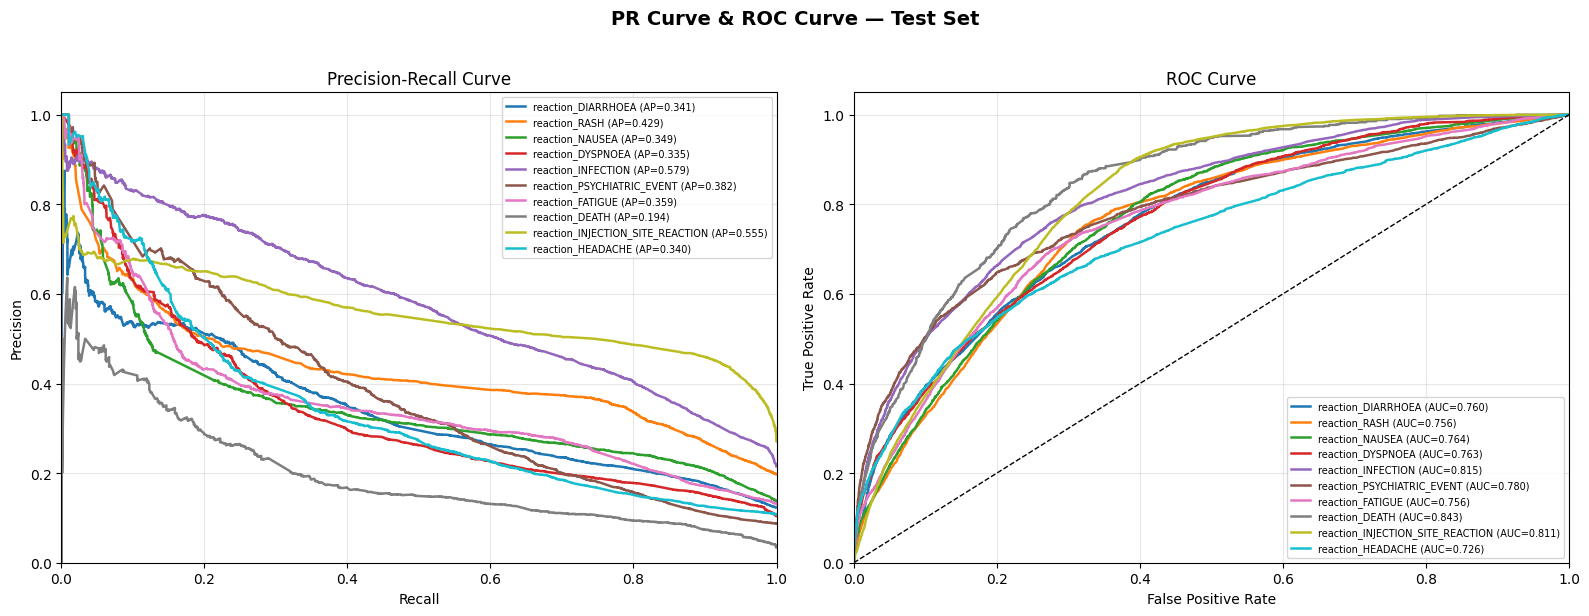

Saved → pr_roc_curves.png


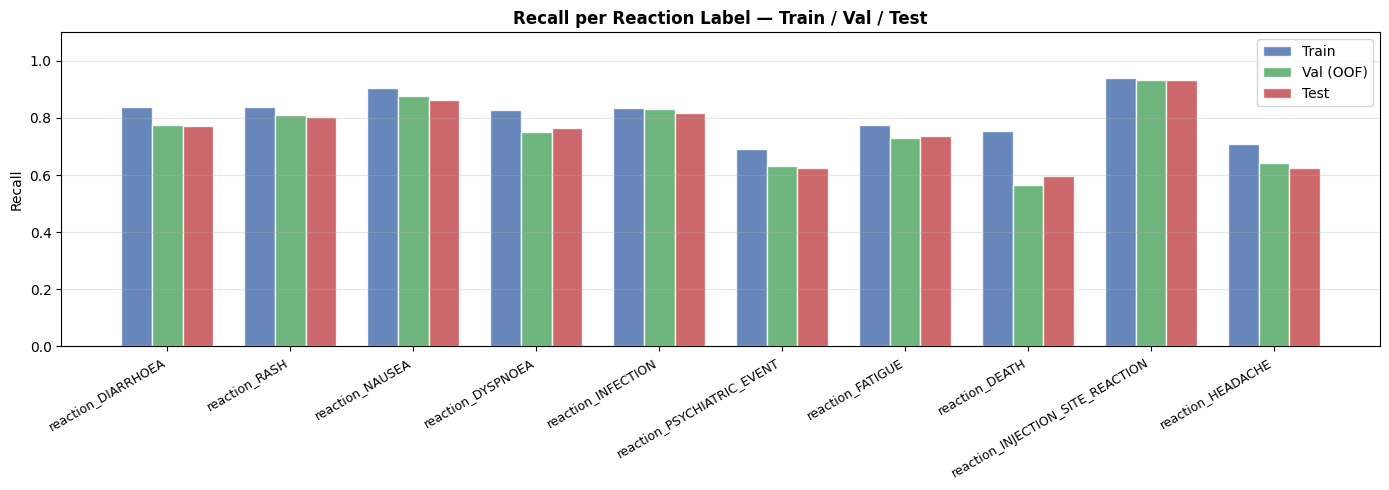

Saved → recall_per_label.png


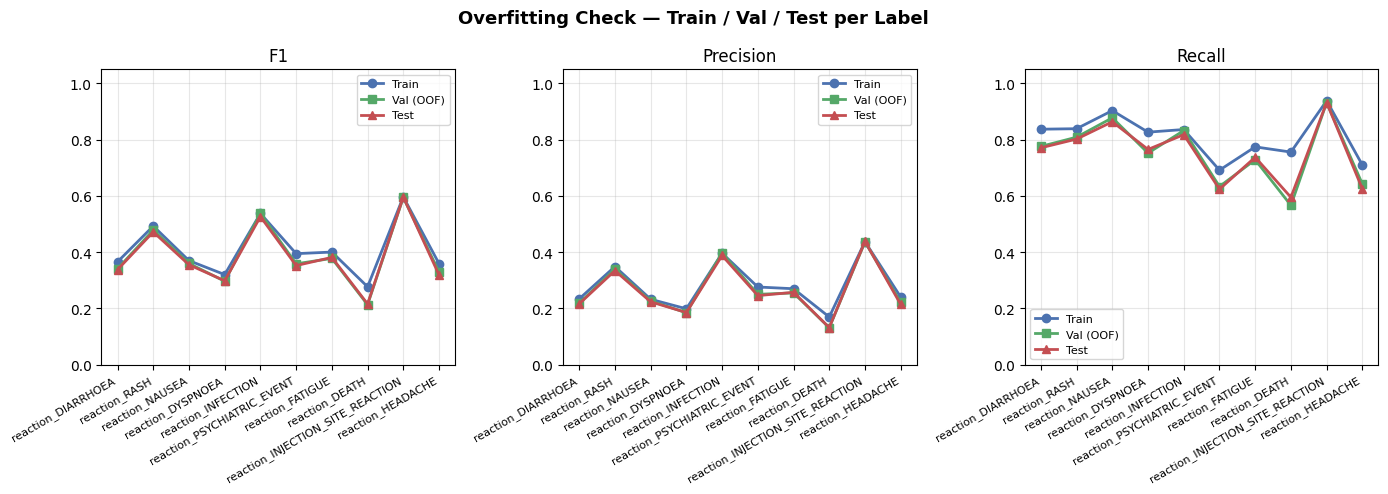

Saved → overfitting_check.png


In [22]:
# ══ RUN ALL THREE ══════════════════════════════════════════════════════════
plot_pr_roc(
    best_model, best_X_test, y_test,
    reaction_cols, best_thresholds, best_mode
)

plot_recall_bars(
    best_model,
    X_train, y_train,   # training set (raw, not OOF)
    X_val,   y_val,     # your validation / OOF set
    best_X_test, y_test,
    reaction_cols, best_thresholds, best_mode
)

plot_overfitting(
    best_model,
    X_train, y_train,
    X_val,   y_val,
    best_X_test, y_test,
    reaction_cols, best_thresholds, best_mode
)

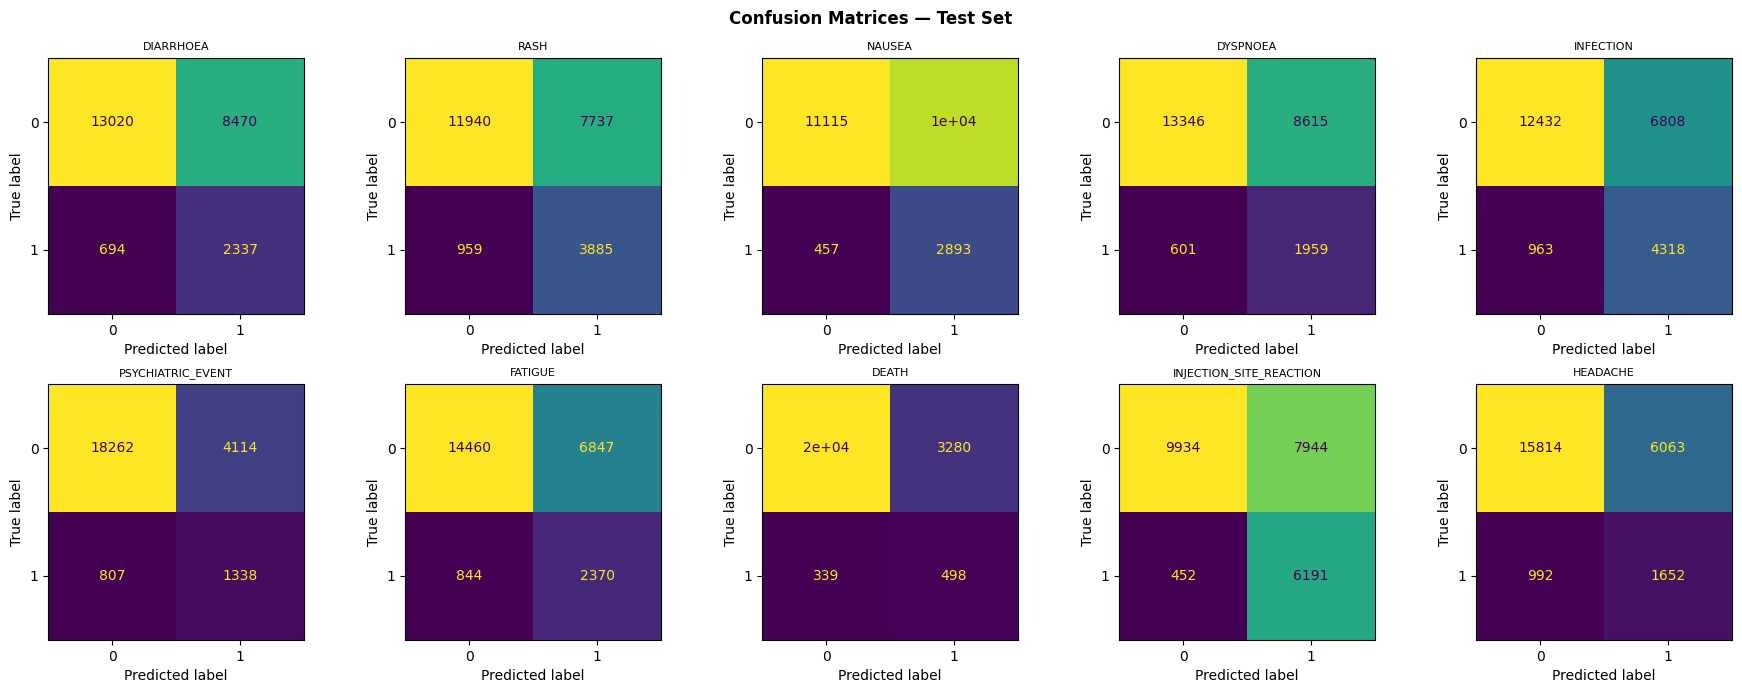

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()
proba = get_proba(best_model, X_test, best_mode)
preds = (proba >= np.array(best_thresholds)).astype(int)

for i, col in enumerate(reaction_cols):
    cm = confusion_matrix(y_test[:, i], preds[:, i])
    ConfusionMatrixDisplay(cm).plot(ax=axes[i], colorbar=False)
    axes[i].set_title(col.replace("reaction_", ""), fontsize=8)

plt.suptitle("Confusion Matrices — Test Set", fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

In [24]:
print(f"\n{'─'*40}")
print(f"  {'Label':<35} {'Threshold':>9}")
print(f"{'─'*40}")
for col, thr in zip(reaction_cols, best_thresholds):
    print(f"  {col:<35} {thr:>9.2f}")
print(f"{'─'*40}")


────────────────────────────────────────
  Label                               Threshold
────────────────────────────────────────
  reaction_DIARRHOEA                       0.46
  reaction_RASH                            0.39
  reaction_NAUSEA                          0.37
  reaction_DYSPNOEA                        0.46
  reaction_INFECTION                       0.38
  reaction_PSYCHIATRIC_EVENT               0.54
  reaction_FATIGUE                         0.43
  reaction_DEATH                           0.65
  reaction_INJECTION_SITE_REACTION         0.29
  reaction_HEADACHE                        0.47
────────────────────────────────────────


In [25]:
print(f"\n{'─'*50}")
print(f"  {'Label':<35} {'Pos%':>6} {'Recall':>8}")
print(f"{'─'*50}")
for i, col in enumerate(reaction_cols):
    pos_rate = y_test[:, i].mean() * 100
    r = recall_score(y_test[:, i], preds[:, i], zero_division=0)
    print(f"  {col:<35} {pos_rate:>5.1f}% {r:>8.4f}")
print(f"{'─'*50}")


──────────────────────────────────────────────────
  Label                                 Pos%   Recall
──────────────────────────────────────────────────
  reaction_DIARRHOEA                   12.4%   0.7710
  reaction_RASH                        19.8%   0.8020
  reaction_NAUSEA                      13.7%   0.8636
  reaction_DYSPNOEA                    10.4%   0.7652
  reaction_INFECTION                   21.5%   0.8176
  reaction_PSYCHIATRIC_EVENT            8.7%   0.6238
  reaction_FATIGUE                     13.1%   0.7374
  reaction_DEATH                        3.4%   0.5950
  reaction_INJECTION_SITE_REACTION     27.1%   0.9320
  reaction_HEADACHE                    10.8%   0.6248
──────────────────────────────────────────────────
